# Quantization Error at Different Bit Widths

### Import Required Libraries

In [20]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### BitWidth Quantization

In [2]:
def quantize_at_bitwidth(tensor, bits):
    q_min = -(2 ** (bits - 1)) + 1
    q_max =  (2 ** (bits - 1)) - 1
    r_max =  tensor.abs().max().item()
    scale = r_max / q_max
    quantized = torch.round(tensor/scale)
    quantized = quantized.clamp(q_min,q_max).to(torch.int32)
    dequantized = quantized.float() * scale
    return quantized, dequantized, scale

### Input

In [14]:
tensor = np.array([[-1.8, -0.9, 0.0, 0.7, 1.5], 
                   [-2.4, -0.3, 0.2, 1.1, 2.0]], dtype=np.float32)
tensor = torch.tensor(tensor)

torch.Size([2, 5])


### Apply quantization at Bit [8, 6, 4]

In [10]:
bit_widths = [8,  6, 4]
results = []
for bit in bit_widths:
    q, dq, scale = quantize_at_bitwidth(tensor, bit)
    mae = torch.abs(tensor - dq).mean()
    mse = torch.abs(tensor - dq).square().mean()
    max_error = torch.abs(tensor - dq).max()
    results.append([bit, -(2**(bit-1))+1, (2**(bit-1))-1, (2**bit)-1, scale, mae, mse, max_error])

### Output

In [11]:
df = pd.DataFrame(results,columns=["Bits","q_min","q_max","Levels","Scale","MAE","MSE","Max Error"])
df

,Bits,q_min,q_max,Levels,Scale,MAE,MSE,Max Error
0,8,-127,127,255,0.018898,tensor(0.0037),tensor(2.1638e-05),tensor(0.0079)
1,6,-31,31,63,0.077419,tensor(0.0152),tensor(0.0004),tensor(0.0323)
2,4,-7,7,15,0.342857,tensor(0.0671),tensor(0.0071),tensor(0.1429)


### Visualization

##### Plot 1 - Original vs Dequantized

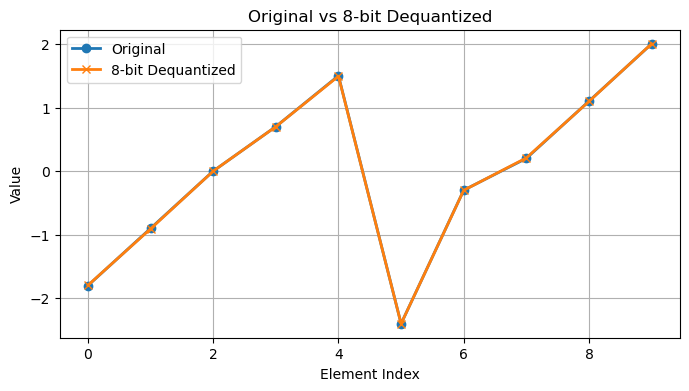

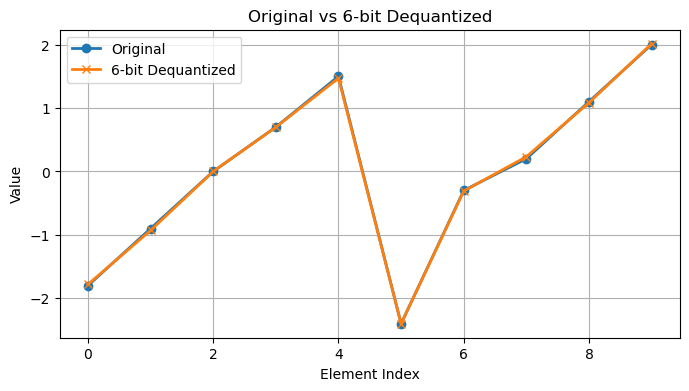

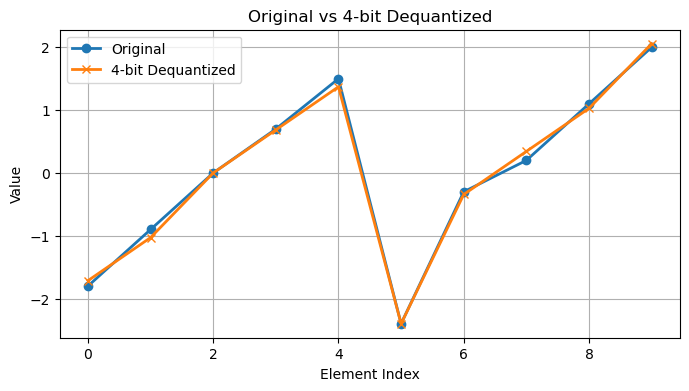

In [21]:
x = np.arange(tensor.numel())
for bits in [8, 6, 4]:
    q, dq, scale = quantize_at_bitwidth(tensor,bits)
    plt.figure(figsize=(8,4))
    plt.plot(x, tensor.flatten(), marker='o', linewidth=2, label='Original')
    plt.plot(x, dq.flatten(), marker='x', linewidth=2, label=f'{bits}-bit Dequantized')
    plt.title(f'Original vs {bits}-bit Dequantized')
    plt.xlabel('Element Index')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.show()

### Plot 2 - MSE vs Bit Width

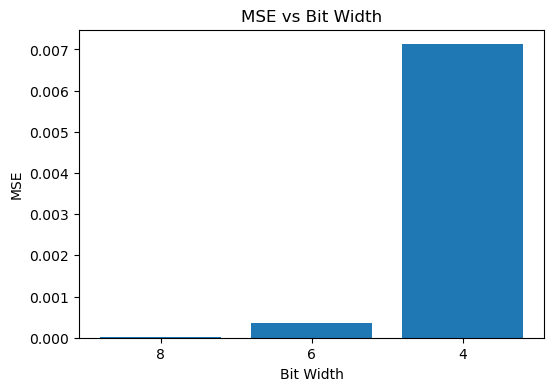

In [22]:
plt.figure(figsize=(6,4))
plt.bar(df["Bits"].astype(str), df["MSE"])
plt.title("MSE vs Bit Width")
plt.xlabel("Bit Width")
plt.ylabel("MSE")
plt.show()

### Plot 3 - Max Error vs Bit Width

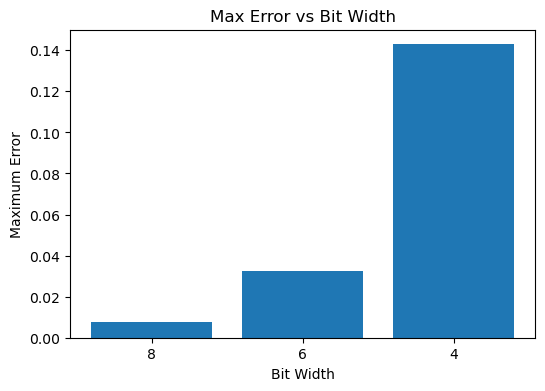

In [23]:
plt.figure(figsize=(6,4))
plt.bar(df["Bits"].astype(str), df["Max Error"])
plt.title("Max Error vs Bit Width")
plt.xlabel("Bit Width")
plt.ylabel("Maximum Error")
plt.show()